### dem down and preprocessing

In [5]:
import rasterio as rio 
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import geopandas as gpd
from utils.get_dem import get_dem
from rasterio.warp import calculate_default_transform, reproject, Resampling


In [14]:
path_setp_vec = 'data/boundary/setp_zhao2022.gpkg'
path_srtm_save = 'data/dem/srtm-c/setp_SRTMGL3.tif'
path_srtm_dsample = 'data/dem/srtm-c/setp_SRTMGL3_005deg.tif'

In [ ]:
# get_dem(demtype='SRTMGL3', bounds=[91, 99.5, 27, 32], 
#         apikey='7f97d1b49489d7c0e346b085772aef3c', path_out=path_srtm_save)


https://portal.opentopography.org/API/globaldem?demtype=SRTMGL3&west=91&east=99.5&south=27&north=32&outputFormat=GTiff&API_Key=7f97d1b49489d7c0e346b085772aef3c
DEM data have been downloaded!


In [ ]:
# target_res = 0.005          # 度
# dst_crs = 'EPSG:4326'
# with rio.open(path_srtm_save) as src:
#     transform, width, height = calculate_default_transform(
#         src.crs, dst_crs, src.width, src.height, *src.bounds,
#         resolution=target_res  
#         )
#     dst_meta = src.meta.copy()
#     dst_meta.update({
#         'crs': dst_crs,
#         'transform': transform,
#         'width': width,
#         'height': height
#     })
#     with rio.open(path_srtm_dsample, 'w', **dst_meta) as dst:
#         reproject(
#             source=rio.band(src, 1),
#             destination=rio.band(dst, 1),
#             src_transform=src.transform,
#             src_crs=src.crs,
#             dst_transform=transform,
#             dst_crs=dst_crs,
#             resampling=Resampling.average    # DEM 用 bilinear 或 average
#         )


In [15]:
setp_vec = gpd.read_file(path_setp_vec)
with rio.open(path_srtm_dsample) as dem_rio:
    dem_meta = dem_rio.meta
    dem_bounds = dem_rio.bounds
    dem_arr = dem_rio.read(1)
dem_extent = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]
print(dem_extent) 


[90.99958333327177, 99.49958333327177, 27.000416666673033, 32.00041666667303]


/tmp/ipykernel_1518149/3571498691.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem_arr = dem_rio.read(1)


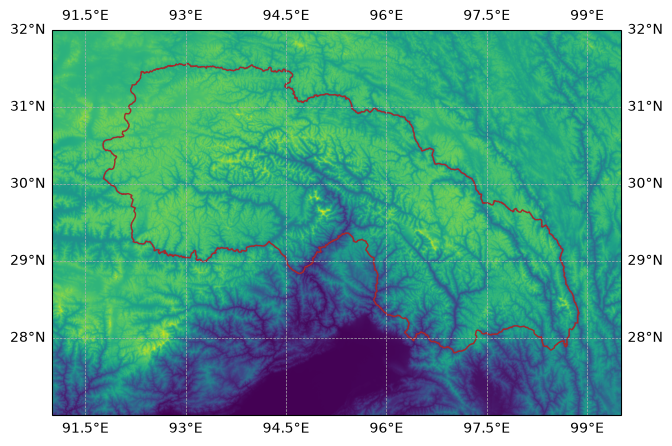

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
im_show = ax.imshow(dem_arr, extent=dem_extent)
setp_vec.plot(ax=ax, transform=ccrs.PlateCarree(), 
             facecolor='none', edgecolor='brown', linewidth=1)
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)
